In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
%matplotlib inline

pd.options.mode.chained_assignment = None

In [2]:
class QAOA():
    """
    Implements QAOA for portfolio optimization using a quantum circuit to solve QUBO problems.
    
    Attributes:
        expected_value (list[float]): Expected returns for each asset.
        cov_matrix (DataFrame-like): Covariance matrix between assets.
        q (float): Scaling factor for covariance.
        B (float): Budget/threshold parameter.
        lamb (float): Penalty factor.
        n_assets (int): Number of assets/qubits.
        qc (QuantumCircuit): Initialized circuit in equal superposition.
    """
    
    def __init__(self, expected_value, cov_matrix, q, B, lamb):
        """
        Initializes the QAOA instance and prepares the quantum circuit.
        
        Args:
            expected_value (list[float]): List of asset returns.
            cov_matrix (DataFrame-like): Covariance matrix.
            q (float): Covariance scaling factor.
            B (float): Budget/threshold parameter.
            lamb (float): Penalty parameter.
        """
        
        self.q = q
        self.B = B
        self.lamb = lamb
        self.expected_value = expected_value
        self.cov_matrix = cov_matrix
        self.n_assets = len(expected_value)
        
        self.qc = QuantumCircuit(self.n_assets, self.n_assets)
        # Initialization - prepare an equal superposition state
        for qubit in range(self.n_assets):
            self.qc.h(qubit)
        self.qc.barrier()
        
    
    def cost_hamiltonian_wheight(self, i, j=None):
        """
        Calculate the weights for the Hamiltonian of the QUBO problem.
        
        Args:
            i (int): Index of the first asset.
            j (int, optional): Index of the second asset. Defaults to None.
            
        Returns:
            float: The weight that multiplies the product of the Z operators, acting on qubits i and j.
        """
        
        if j is None:
            response =2*self.expected_value[i]+2*self.lamb*(2*self.B-self.n_assets)-self.q*self.cov_matrix[i].drop([i], axis=0).sum()
        else:
            response = q*self.cov_matrix[i][j]+2*self.lamb
        return response
    
    def draw(self):
        """
        Draws the quantum circuit using matplotlib.
        """
        self.qc.draw(output="mpl", style="iqp")
    
    def add_layer(self, gamma, beta):
        """
        Adds one QAOA layer to the circuit.
        
        This layer applies:
            - Cost Hamiltonian: exp(-i*gamma*H_c) using CNOT and RZ gates.
            - Mixing Hamiltonian: exp(-i*beta*H_B) using RX gates.
        
        Args:
            gamma (float): Parameter for the cost Hamiltonian.
            beta (float): Parameter for the mixing Hamiltonian.
        """
        
        # Implement exp(-i*gamma*H_c)
        # H_c: Cost Hamiltonian
        for i in range(self.n_assets):
            for j in range(i+1, self.n_assets):
                self.qc.cx(i, j)
                self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(i, j), j)
                self.qc.cx(i, j)
        for qubit in range(self.n_assets):
            self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(qubit), qubit)
        self.qc.barrier()
                
        # Implement exp(-i*beta*H_B)
        # H_B = sum(X_i): Mixture Hamiltonian
        for qubit in range(self.n_assets):
             self.qc.rx(2*self.cost_hamiltonian_wheight(qubit)*beta, qubit)
        self.qc.barrier()
             
    def measure_energy(self):
        """
        Measures the circuit and computes the expected energy.
        
        Returns:
            tuple: (energy, counts) where energy is the expected value and counts is the measurement distribution.
    
        """
        
        self.qc.measure(range(self.n_assets), range(self.n_assets))

        simulator = AerSimulator()
        compiled_circuit = transpile(self.qc, simulator)
        sim_result = simulator.run(self.qc).result()
        counts = sim_result.get_counts()
        
        energy = 0
        total_shots = sum(counts.values())
        for bitstring, count in counts.items():
            prob = count / total_shots
            
            Z = [1 if bitstring[::-1][i] == '0' else -1 for i in range(self.n_assets)]
            
            energy_outcome = 0
            for i in range(self.n_assets):
                energy_outcome += self.cost_hamiltonian_wheight(i)*Z[i]
                for j in range(i+1, self.n_assets):
                    energy_outcome += self.cost_hamiltonian_wheight(i, j)*Z[i]*Z[j]
            
            energy += prob * energy_outcome
        
        return energy, counts
        

In [3]:
def f_data_pre_train(depth, expected_value, cov_matrix, q, B, lamb):
    """
    Builds a QAOA circuit with a specified number of random layers and returns training data.

    Args:
        depth (int): The number of QAOA layers to add.
        expected_value (list[float]): List of asset returns.
        cov_matrix (DataFrame-like): Covariance matrix.
        q (float): Covariance scaling factor.
        B (float): Budget/threshold parameter.
        lamb (float): Penalty parameter.

    Returns:
        dict: A dictionary containing:
            - 'vec_beta': List of beta values for each layer.
            - 'vec_gamma': List of gamma values for each layer.
            - 'count': Measurement outcome counts from the simulation.
            - 'energy': The computed expected energy.
    """
    qaoa = QAOA(expected_value, cov_matrix, q, B, lamb)
    vec_gamma = []
    vec_beta = []
    for _ in range(depth):
        gamma = np.random.uniform(0, 2*np.pi)
        beta = np.random.uniform(0, np.pi)
        vec_gamma.append(gamma)
        vec_beta.append(beta)
        qaoa.add_layer(gamma, beta)
        
    energy, count = qaoa.measure_energy()
    response = {
        'vec_beta': vec_beta,
        'vec_gamma': vec_gamma,
        'count': count,
        'energy': energy
    }
        
    return response

## Pre train data

In [4]:
expected_value = [0.335649, 0.084554, 0.357477, 0.148336]
cov_matrix = pd.DataFrame([
 [0.001077, 0.000257,0.000320,0.000190],
 [0.000257,	0.000441,0.000228,0.000084],
 [0.000320,	0.000228, 0.000867,0.000154],
 [0.000190,	0.000084,0.000154,0.000420]
])

q = 0.5 
B  = 2 
lamb= 1

In [5]:
qt_simulations = 100
depth = 10

In [6]:
data = []
for _ in tqdm(range(qt_simulations)):
    d = f_data_pre_train(depth, expected_value, cov_matrix, q, B, lamb)
    data.append(d)
    
df0 = pd.DataFrame(data).sort_values('energy').reset_index(drop=True)
df0.head(4)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:19<00:00,  5.23it/s]


,vec_beta,vec_gamma,count,energy
0,"[1.6261444898258104, 2.3710903920345516, 3.056...","[2.1556973198608667, 0.8781602180593568, 5.412...","{'0001': 16, '0111': 4, '0011': 198, '1011': 1...",-2.046583
1,"[2.3771579065496193, 1.2674049448982876, 2.123...","[0.585954222909215, 1.976866127700232, 0.87647...","{'0010': 2, '1110': 17, '1100': 92, '1000': 13...",-1.985821
2,"[0.6438859128745926, 0.9752746949968021, 1.178...","[0.2154219986668509, 6.0882895244278865, 1.728...","{'0100': 9, '1010': 18, '1111': 16, '1100': 14...",-1.660030
3,"[0.9728034344658072, 2.2852371191271232, 3.123...","[0.12574074731738555, 5.457032536834101, 0.490...","{'1111': 5, '0100': 7, '0001': 5, '0000': 41, ...",-1.588218


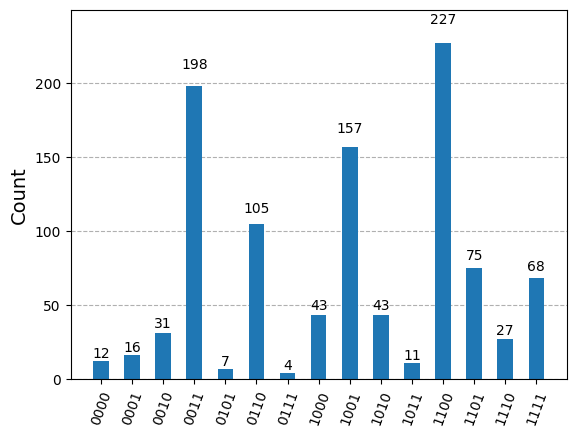

In [7]:
plot_histogram(df0.iloc[0]['count'])
plt.show()

# Variational Autoencoder

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

In [9]:
class VAE(nn.Module):
    """
    A Variational Autoencoder (VAE) for unsupervised representation learning.

    Attributes:
        encoder (nn.Sequential): Maps the input to the latent Gaussian parameters (mean and log-variance).
        decoder (nn.Sequential): Reconstructs the input from the latent representation.
        latent_dim (int): Dimensionality of the latent space.
    """
    
    def __init__(self, input_dim=2*depth, latent_dim=5):
        """
        Initializes the VAE with specified input and latent dimensions.

        Args:
            input_dim (int): Dimensionality of the input data (default: 2*depth).
            latent_dim (int): Dimensionality of the latent space (default: 5).
        """
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim*2)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )
        
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        """
        Applies the reparameterization trick to sample from a Gaussian distribution.

        Args:
            mu (Tensor): Mean of the latent Gaussian.
            logvar (Tensor): Log-variance of the latent Gaussian.

        Returns:
            Tensor: A sample from the latent distribution.
        """
        
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """
        Performs a forward pass through the VAE.

        Args:
            x (Tensor): Input tensor.

        Returns:
            tuple: (reconstructed input, latent mean, latent log-variance).
        """
        
        x = self.encoder(x)
        mu, logvar = x[:, :self.latent_dim], x[:, self.latent_dim:]
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
    
    def vae_eval(self, mean=0, std=1):
        """
        Generates QAOA parameters from the VAE and simulates a QAOA circuit.

        Args:
            mean (float, optional): Mean for sampling the latent vector (default: 0).
            std (float, optional): Standard deviation for sampling the latent vector (default: 1).

        Returns:
            dict: A dictionary containing:
                - 'vec_beta': List of beta parameters.
                - 'vec_gamma': List of gamma parameters.
                - 'count': Measurement outcome counts from the QAOA simulation.
                - 'energy': Computed energy of the QAOA circuit.
        """
        
        self.eval()
        with torch.no_grad():
            z = torch.normal(mean=mean, std=std, size=(1, latent_dim))
            generated_sequence = self.decoder(z).squeeze().numpy()
        vec_gamma = generated_sequence[:depth]
        vec_beta = generated_sequence[depth:]
        qaoa = QAOA(expected_value, cov_matrix, q, B, lamb)
        for i in range(depth):
            qaoa.add_layer(vec_gamma[i], vec_beta[i])
        energy, count = qaoa.measure_energy()
        
        response = {
                    'vec_beta': list(vec_beta),
                    'vec_gamma': list(vec_gamma),
                    'count': count,
                    'energy': energy
                }
        
        return response, qaoa
    
def vae_loss(recon_x, x, mu, logvar):
    """
    Loss function for VAE optimization.
    
    Args:
        recon_x (Tensor): Reconstructed output.
        x (Tensor): Ground truth input.
        mu, logvar (Tensor): Latent space parameters.
    
    Returns:
        float: Loss function evaluation
    """
    # Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence (regularization for latent space)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [10]:
def epoch_train(X, vae, optimizer, qt_simulations, mean=0, std=1):
    """
    Performs one training epoch for the VAE and collects QAOA simulation data.

    The function executes a training step on the VAE with input X (forward pass, loss computation,
    backpropagation, and optimizer update). It then runs a number of QAOA simulations using the updated
    VAE model to generate QAOA parameters and measure the circuit energy.

    Args:
        X (Tensor): Input batch for VAE training.
        vae (VAE): Variational Autoencoder model.
        optimizer (Optimizer): Optimizer for updating the VAE parameters.
        qt_simulations (int): Number of QAOA simulations to perform.
        mean (float, optional): Mean for latent vector sampling (default: 0).
        std (float, optional): Standard deviation for latent vector sampling (default: 1).

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: Simulation data with columns 'vec_beta', 'vec_gamma', 'count', and 'energy'.
            - float: The VAE loss value for the epoch.
    """
    
    recon_x, mu, logvar = vae(X)
    
    optimizer.zero_grad()
    loss = vae_loss(recon_x, X, mu, logvar)
    loss.backward()
    optimizer.step()
    
    data = []
    for _ in range(qt_simulations):
        d, qaoa = vae.vae_eval(mean=mean, std=std)
        data.append(d)
    
    return pd.DataFrame(data), loss.item()

In [11]:
# Initialize model and optimizer
latent_dim = 5
vae = VAE(latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.1)
epochs = 10
qt_simulations = 50

In [12]:
df_i = df0.copy()
df = df0.copy()
df_epochs = df_i[['energy']]
df_epochs['epoch'] = 0
print(f"Epoch 0, Energy mean: {df_i['energy'].mean():.2f}")
for i in range(1, epochs+1):
    # Concatenate the aggregated data (df) with the current simulation data (df_i),
    # sort by energy, and select the top 'qt_simulations' entries.
    # This strategy ensures that the model focuses on learning to generate states with low energy.
    df = pd.concat([df, df_i]).sort_values('energy').head(qt_simulations).reset_index(drop=True)
    X = torch.tensor(df['vec_beta']+df['vec_gamma'], dtype=torch.float32)
    
    df_i, loss_item = epoch_train(X, vae, optimizer, qt_simulations, mean=0, std=2)
    df_epochs_i = df_i[['energy']]
    df_epochs_i['epoch'] = i
    df_epochs = pd.concat([df_epochs, df_epochs_i])
    print(f"Epoch {i}, Loss: {loss_item:.2f}, Energy mean: {df_i['energy'].mean():.2f}")

Epoch 0, Energy mean: 0.34
Epoch 1, Loss: 6413.27, Energy mean: 0.20
Epoch 2, Loss: 7084159.00, Energy mean: -0.18
Epoch 3, Loss: 4577.14, Energy mean: -0.52
Epoch 4, Loss: 4104.20, Energy mean: -0.58
Epoch 5, Loss: 4048.26, Energy mean: -0.61
Epoch 6, Loss: 4290.29, Energy mean: -0.58
Epoch 7, Loss: 4370.74, Energy mean: -0.62
Epoch 8, Loss: 4301.80, Energy mean: -0.61
Epoch 9, Loss: 4194.13, Energy mean: -0.58
Epoch 10, Loss: 3906.61, Energy mean: -0.56


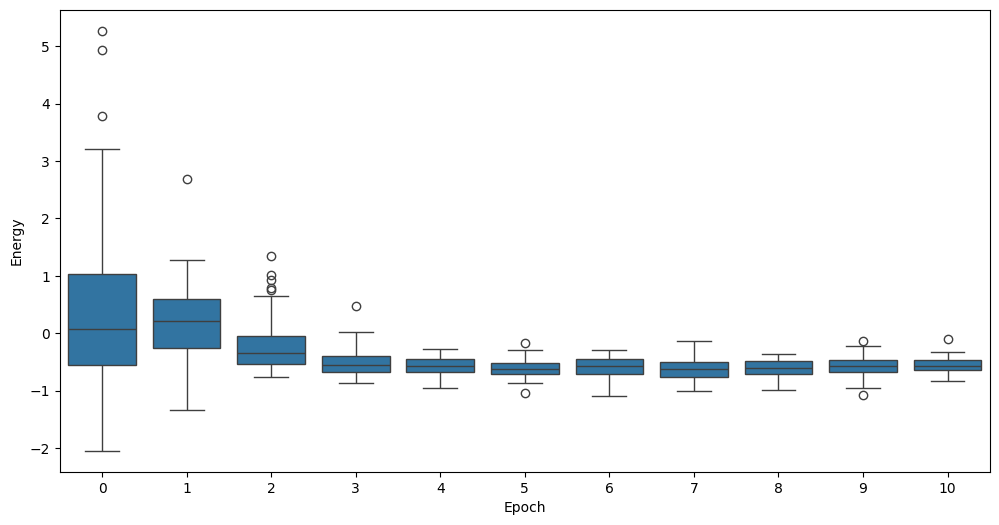

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='epoch', y='energy', data=df_epochs)
plt.xlabel('Epoch')
plt.ylabel('Energy')
plt.show()

In [14]:
d, qaoa = vae.vae_eval(mean=0, std=1)

In [15]:
d['energy']

np.float64(-0.41943763281250057)

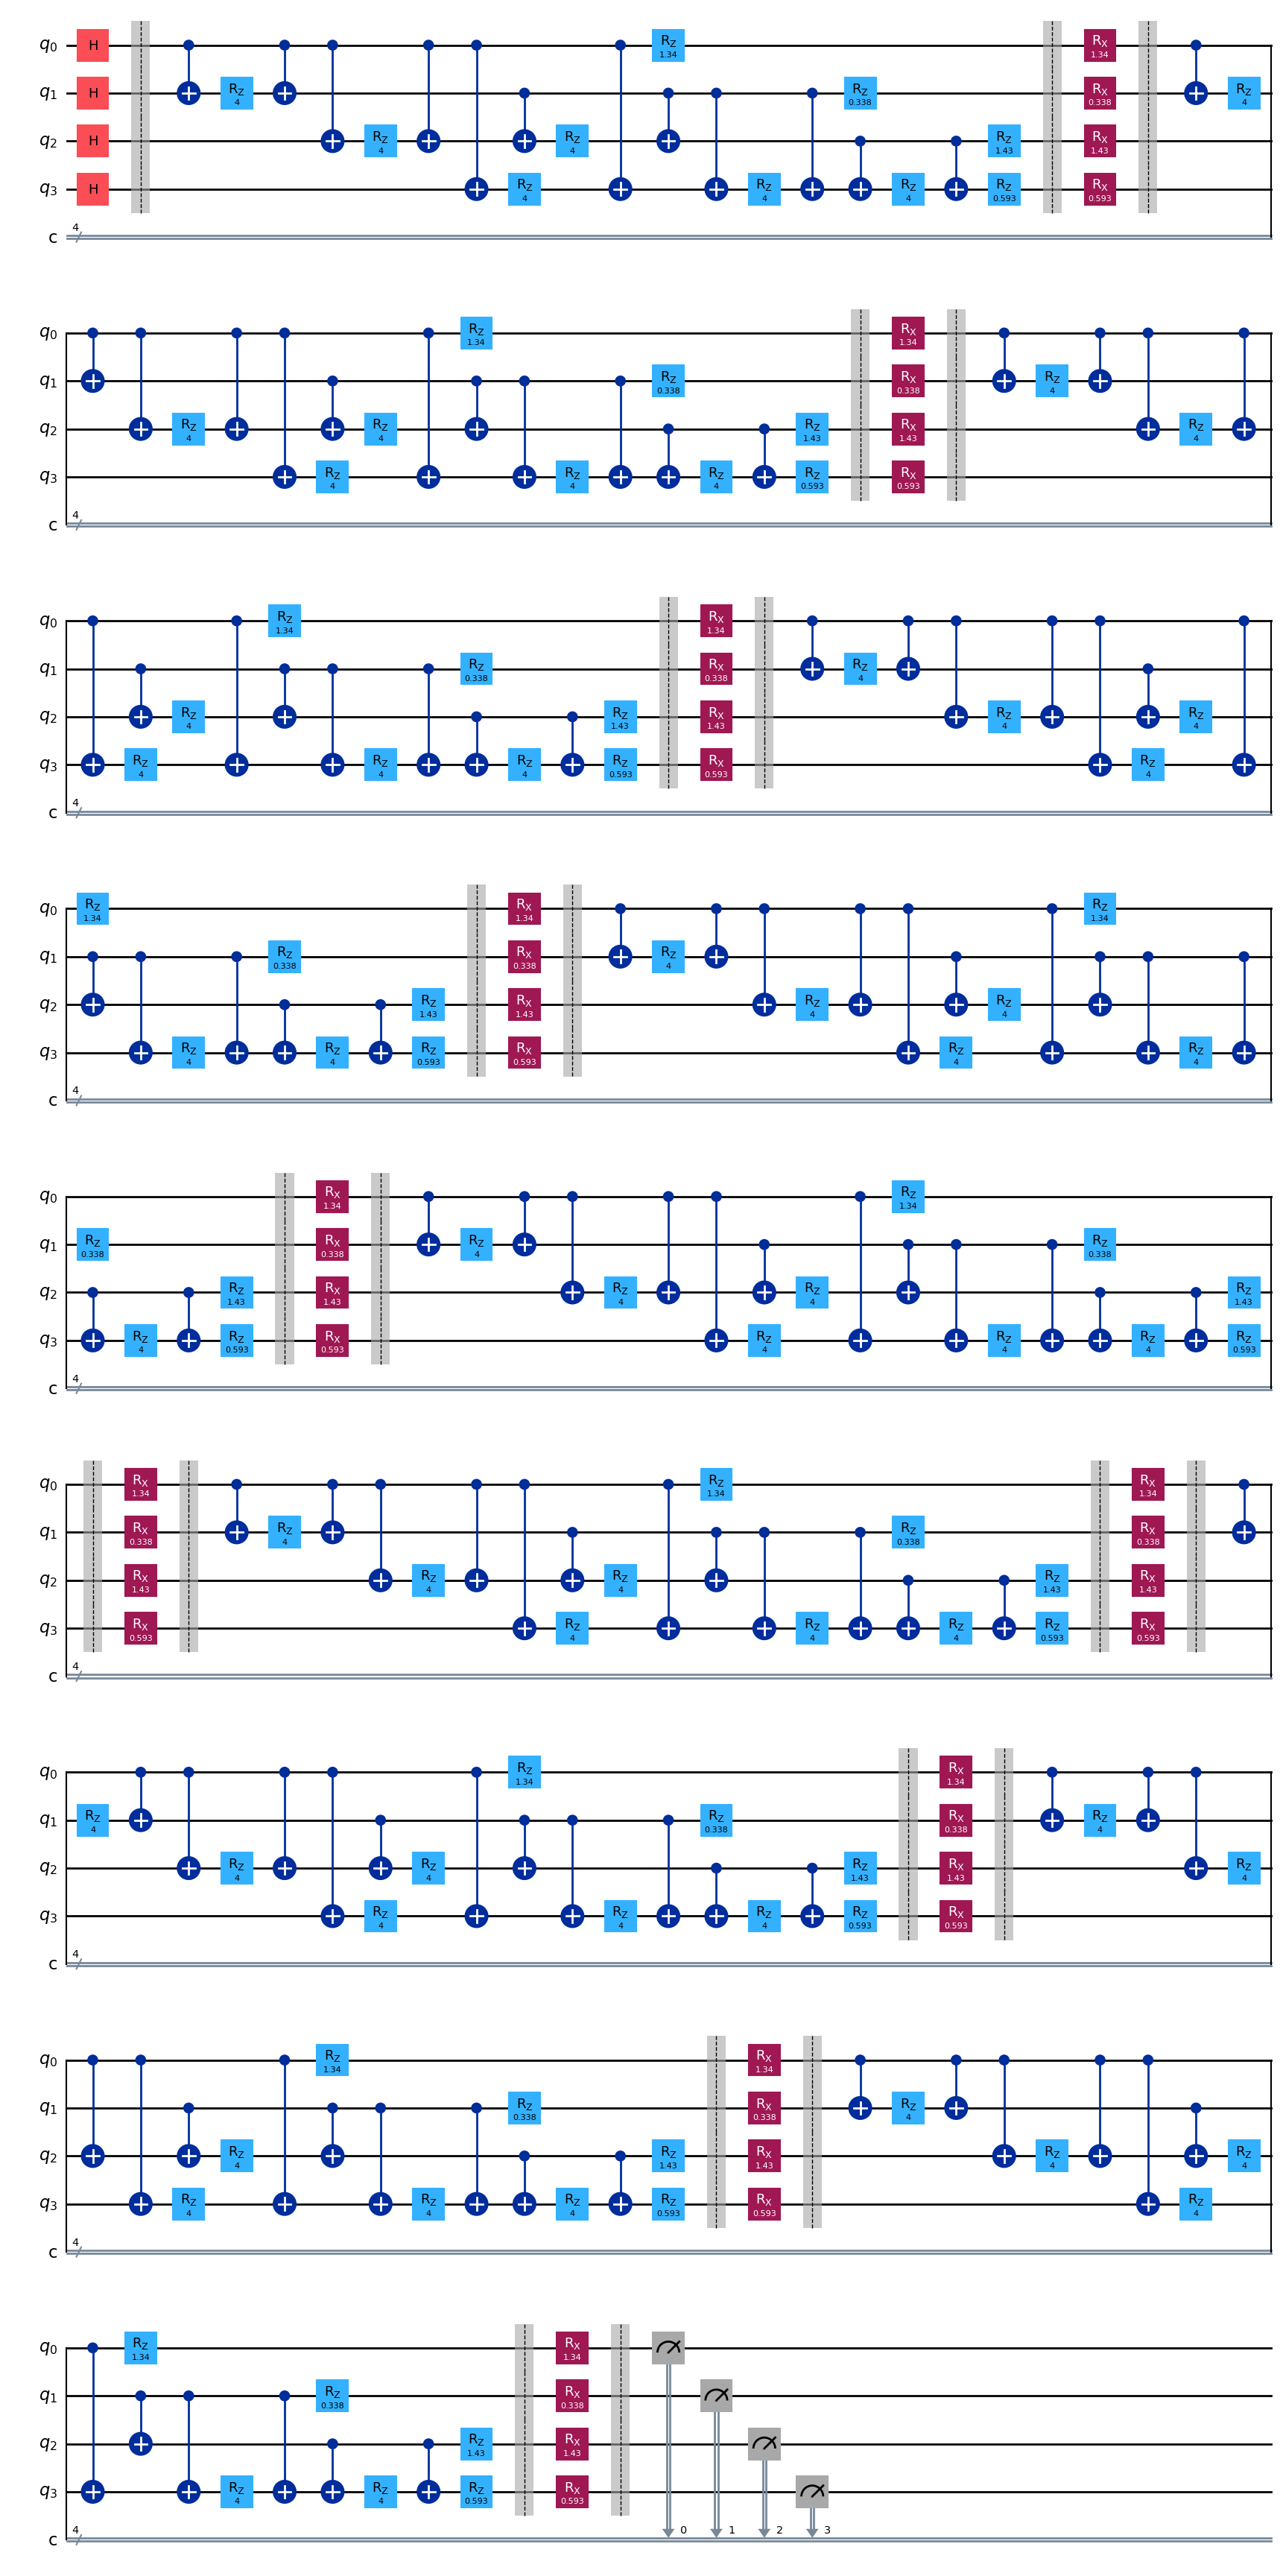

In [16]:
qaoa.draw()